In [211]:
from google.colab import files

uploaded = files.upload()

Saving Sales_Analysis_Dataset.xlsx to Sales_Analysis_Dataset (28).xlsx


In [212]:
from google.colab import files

files.download(output_file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

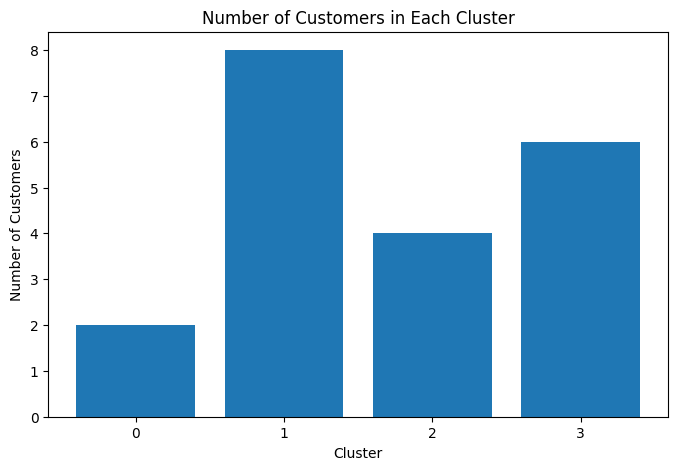

In [213]:
# ============================================
# CLUSTER SIZE VISUALIZATION
# ============================================

cluster_counts = final_data["Cluster"].value_counts().sort_index()

plt.figure(figsize=(8, 5))

plt.bar(
    cluster_counts.index.astype(str),
    cluster_counts.values
)

plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.title("Number of Customers in Each Cluster")

plt.show()

In [214]:
# ============================================
# SAVE FINAL RESULTS
# ============================================

output_file = "Sales_Customer_Segmentation_Final.xlsx"

final_data.to_excel(
    output_file,
    index=False
)

print("Final dataset saved successfully!")
print("File:", output_file)

Final dataset saved successfully!
File: Sales_Customer_Segmentation_Final.xlsx


In [215]:
# ============================================
# PCA ON CLUSTERED DATA
# ============================================

from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

clustered_data["PCA1"] = X_pca[:, 0]
clustered_data["PCA2"] = X_pca[:, 1]

print("PCA completed successfully!")

print(
    f"\nTotal explained variance: "
    f"{pca.explained_variance_ratio_.sum() * 100:.2f}%"
)

PCA completed successfully!

Total explained variance: 74.85%


K-MEANS + PCA COMPLETED

Final dataset columns:
['Customer_Name', 'Total_Sales', 'Total_Profit', 'Total_Quantity', 'Average_Discount', 'Average_Profit_Margin', 'Number_of_Orders', 'Average_Order_Value', 'Cluster', 'PCA1', 'PCA2']

Cluster distribution:
Cluster
0    2
1    8
2    4
3    6
Name: count, dtype: int64

PCA explained variance:
PCA1: 49.69%
PCA2: 25.16%
Total: 74.85%

Cluster Summary:


,Total_Sales,Total_Profit,Total_Quantity,Average_Discount,Average_Profit_Margin,Number_of_Orders,Average_Order_Value
Cluster,,,,,,,
0,144865.00,6665.14,794.50,0.13,8.96,250.50,579.16
1,113071.95,6081.48,720.25,0.12,10.44,238.00,476.40
2,145656.35,7900.84,842.75,0.12,9.81,271.75,536.53
3,116426.58,5523.00,775.67,0.13,9.86,251.33,463.50


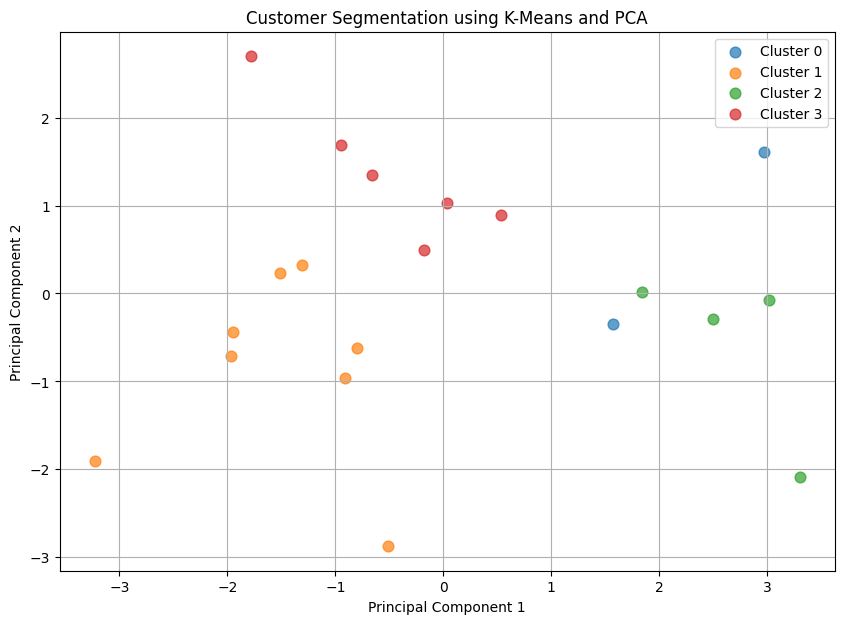

In [216]:
# ============================================================
# FINAL K-MEANS + PCA — ALL-IN-ONE
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# ------------------------------------------------------------
# 1. K-MEANS
# ------------------------------------------------------------

optimal_k = 4

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X_scaled)

# Create a fresh dataframe
final_data = customer_data.copy()

# Add clusters
final_data["Cluster"] = cluster_labels


# ------------------------------------------------------------
# 2. PCA
# ------------------------------------------------------------

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

# Add PCA columns
final_data["PCA1"] = X_pca[:, 0]
final_data["PCA2"] = X_pca[:, 1]


# ------------------------------------------------------------
# 3. CHECK EVERYTHING
# ------------------------------------------------------------

print("============================================")
print("K-MEANS + PCA COMPLETED")
print("============================================")

print("\nFinal dataset columns:")
print(final_data.columns.tolist())

print("\nCluster distribution:")
print(final_data["Cluster"].value_counts().sort_index())

print("\nPCA explained variance:")
print(f"PCA1: {pca.explained_variance_ratio_[0] * 100:.2f}%")
print(f"PCA2: {pca.explained_variance_ratio_[1] * 100:.2f}%")
print(
    f"Total: "
    f"{pca.explained_variance_ratio_.sum() * 100:.2f}%"
)


# ------------------------------------------------------------
# 4. CLUSTER SUMMARY
# ------------------------------------------------------------

cluster_summary = final_data.groupby("Cluster")[features].mean()

print("\nCluster Summary:")
display(cluster_summary.round(2))


# ------------------------------------------------------------
# 5. PCA VISUALIZATION
# ------------------------------------------------------------

plt.figure(figsize=(10, 7))

for cluster in sorted(final_data["Cluster"].unique()):

    cluster_data = final_data[
        final_data["Cluster"] == cluster
    ]

    plt.scatter(
        cluster_data["PCA1"],
        cluster_data["PCA2"],
        s=60,
        alpha=0.7,
        label=f"Cluster {cluster}"
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Segmentation using K-Means and PCA")

plt.legend()
plt.grid(True)

plt.show()

In [217]:
# ============================================
# PCA EXPLAINED VARIANCE
# ============================================

pca1_variance = pca.explained_variance_ratio_[0] * 100
pca2_variance = pca.explained_variance_ratio_[1] * 100
total_variance = pca.explained_variance_ratio_.sum() * 100

print(f"PCA1 explains: {pca1_variance:.2f}%")
print(f"PCA2 explains: {pca2_variance:.2f}%")
print(f"Total explained variance: {total_variance:.2f}%")

PCA1 explains: 49.69%
PCA2 explains: 25.16%
Total explained variance: 74.85%


In [218]:
# ============================================
# K-MEANS + CLUSTER SUMMARY - FINAL
# ============================================

from sklearn.cluster import KMeans

# Recreate K-Means using the existing standardized data
optimal_k = 4

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

# Generate cluster labels
cluster_labels = kmeans.fit_predict(X_scaled)

# Create a fresh copy so previous cells cannot remove Cluster
clustered_data = customer_data.copy()

# Add cluster labels
clustered_data["Cluster"] = cluster_labels

# Calculate cluster summary
cluster_summary = clustered_data.groupby("Cluster")[features].mean()

print("K-Means clustering completed!")
print("\nCluster sizes:")
print(clustered_data["Cluster"].value_counts().sort_index())

print("\nCluster Summary:")
display(cluster_summary.round(2))

K-Means clustering completed!

Cluster sizes:
Cluster
0    2
1    8
2    4
3    6
Name: count, dtype: int64

Cluster Summary:


,Total_Sales,Total_Profit,Total_Quantity,Average_Discount,Average_Profit_Margin,Number_of_Orders,Average_Order_Value
Cluster,,,,,,,
0,144865.00,6665.14,794.50,0.13,8.96,250.50,579.16
1,113071.95,6081.48,720.25,0.12,10.44,238.00,476.40
2,145656.35,7900.84,842.75,0.12,9.81,271.75,536.53
3,116426.58,5523.00,775.67,0.13,9.86,251.33,463.50


In [219]:
# ============================================
# PCA EXPLAINED VARIANCE
# ============================================

pca1_variance = pca.explained_variance_ratio_[0] * 100
pca2_variance = pca.explained_variance_ratio_[1] * 100
total_variance = pca.explained_variance_ratio_.sum() * 100

print(f"PCA1 explains: {pca1_variance:.2f}%")
print(f"PCA2 explains: {pca2_variance:.2f}%")
print(f"Total explained variance: {total_variance:.2f}%")

PCA1 explains: 49.69%
PCA2 explains: 25.16%
Total explained variance: 74.85%


K-Means completed successfully!
PCA completed successfully!
PCA1 explains: 49.69%
PCA2 explains: 25.16%
Total explained variance: 74.85%

Cluster distribution:
Cluster
0    2
1    8
2    4
3    6
Name: count, dtype: int64

PCA data:


,Customer_Name,Cluster,PCA1,PCA2
0,Aarav Mehta,1,-3.225568,-1.899784
1,Aditya Rao,1,-1.310083,0.321351
2,Aisha Khan,1,-1.513638,0.228440
3,Ananya Iyer,0,1.570114,-0.351192
4,Arjun Nair,3,0.033947,1.025450
5,Dev Agarwal,1,-0.801717,-0.618784
6,Diya Sharma,3,-0.177954,0.489347
7,Ishita Gupta,2,3.298316,-2.091117
8,Kabir Shah,3,-1.784533,2.697741
9,Kiara Desai,3,-0.948475,1.683366


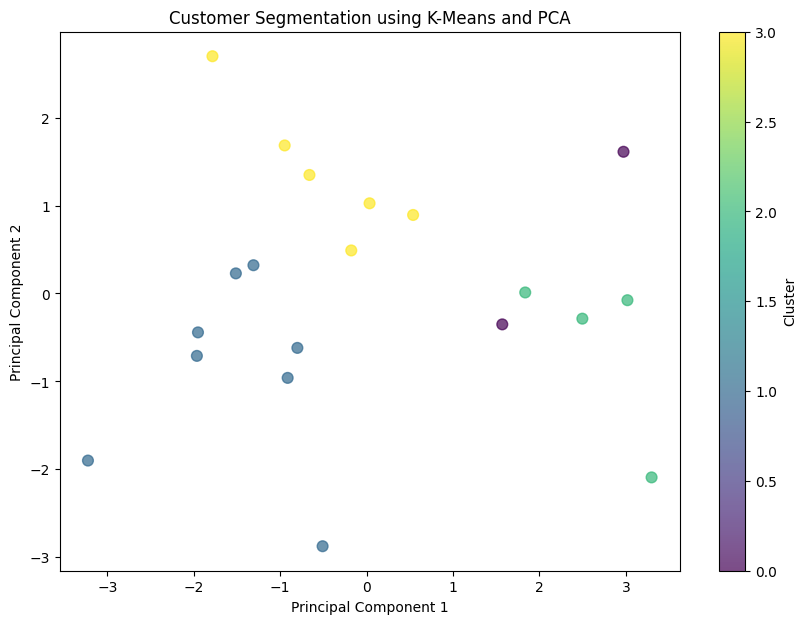

In [220]:
# ============================================================
# COMPLETE K-MEANS + PCA ANALYSIS
# ============================================================

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. K-MEANS CLUSTERING
# ------------------------------------------------------------

optimal_k = 4

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

# Create cluster labels
cluster_labels = kmeans.fit_predict(X_scaled)

# Add cluster labels
customer_data["Cluster"] = cluster_labels

print("K-Means completed successfully!")


# ------------------------------------------------------------
# 2. PCA
# ------------------------------------------------------------

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

# Add PCA components
customer_data["PCA1"] = X_pca[:, 0]
customer_data["PCA2"] = X_pca[:, 1]

print("PCA completed successfully!")


# ------------------------------------------------------------
# 3. PCA EXPLAINED VARIANCE
# ------------------------------------------------------------

pca1 = pca.explained_variance_ratio_[0] * 100
pca2 = pca.explained_variance_ratio_[1] * 100

print(f"PCA1 explains: {pca1:.2f}%")
print(f"PCA2 explains: {pca2:.2f}%")
print(f"Total explained variance: {pca1 + pca2:.2f}%")


# ------------------------------------------------------------
# 4. CHECK DATA
# ------------------------------------------------------------

print("\nCluster distribution:")
print(customer_data["Cluster"].value_counts().sort_index())

print("\nPCA data:")
display(
    customer_data[
        ["Customer_Name", "Cluster", "PCA1", "PCA2"]
    ].head(10)
)


# ------------------------------------------------------------
# 5. VISUALIZATION
# ------------------------------------------------------------

plt.figure(figsize=(10, 7))

plt.scatter(
    customer_data["PCA1"],
    customer_data["PCA2"],
    c=customer_data["Cluster"],
    cmap="viridis",
    s=60,
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Segmentation using K-Means and PCA")

plt.colorbar(label="Cluster")

plt.show()

In [221]:
# ============================================
# K-MEANS + PCA - COMPLETE STEP
# ============================================

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# -----------------------------
# 1. K-Means Clustering
# -----------------------------

optimal_k = 4

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

customer_data["Cluster"] = kmeans.fit_predict(X_scaled)

print("K-Means completed successfully!")


# -----------------------------
# 2. PCA
# -----------------------------

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

customer_data["PCA1"] = X_pca[:, 0]
customer_data["PCA2"] = X_pca[:, 1]

print("PCA completed successfully!")


# -----------------------------
# 3. Check result
# -----------------------------

print("\nFinal columns:")
print(customer_data.columns.tolist())

print("\nFirst 10 customers:")
display(
    customer_data[
        ["Customer_Name", "Cluster", "PCA1", "PCA2"]
    ].head(10)
)

K-Means completed successfully!
PCA completed successfully!

Final columns:
['Customer_Name', 'Total_Sales', 'Total_Profit', 'Total_Quantity', 'Average_Discount', 'Average_Profit_Margin', 'Number_of_Orders', 'Average_Order_Value', 'Cluster', 'PCA1', 'PCA2']

First 10 customers:


,Customer_Name,Cluster,PCA1,PCA2
0,Aarav Mehta,1,-3.225568,-1.899784
1,Aditya Rao,1,-1.310083,0.321351
2,Aisha Khan,1,-1.513638,0.228440
3,Ananya Iyer,0,1.570114,-0.351192
4,Arjun Nair,3,0.033947,1.025450
5,Dev Agarwal,1,-0.801717,-0.618784
6,Diya Sharma,3,-0.177954,0.489347
7,Ishita Gupta,2,3.298316,-2.091117
8,Kabir Shah,3,-1.784533,2.697741
9,Kiara Desai,3,-0.948475,1.683366


In [222]:
# ============================================
# PCA DIMENSIONALITY REDUCTION
# ============================================

from sklearn.decomposition import PCA

# Reduce 7 features to 2 principal components
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

# Add PCA components to customer dataset
customer_data["PCA1"] = X_pca[:, 0]
customer_data["PCA2"] = X_pca[:, 1]

print("PCA completed successfully!")
print("Original number of features:", X_scaled.shape[1])
print("Reduced number of features:", X_pca.shape[1])

PCA completed successfully!
Original number of features: 7
Reduced number of features: 2


In [223]:
# ============================================
# K-MEANS CLUSTERING
# ============================================

optimal_k = 4

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

customer_data["Cluster"] = kmeans.fit_predict(X_scaled)

print("K-Means clustering completed!")
print("\nCustomers per cluster:")
print(customer_data["Cluster"].value_counts().sort_index())

K-Means clustering completed!

Customers per cluster:
Cluster
0    2
1    8
2    4
3    6
Name: count, dtype: int64


In [224]:
# ============================================
# K-MEANS + CLUSTER SUMMARY
# ============================================

from sklearn.cluster import KMeans

# Set number of clusters
optimal_k = 4

# Create K-Means model
kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

# Generate cluster labels
cluster_labels = kmeans.fit_predict(X_scaled)

# Add labels to customer_data
customer_data["Cluster"] = cluster_labels

# Verify Cluster was created
print("Cluster column created successfully!")
print("\nColumns:")
print(customer_data.columns.tolist())

print("\nCustomers per cluster:")
print(customer_data["Cluster"].value_counts().sort_index())

# Create cluster summary
cluster_summary = customer_data.groupby("Cluster")[features].mean()

print("\nCluster Summary:")
display(cluster_summary.round(2))

Cluster column created successfully!

Columns:
['Customer_Name', 'Total_Sales', 'Total_Profit', 'Total_Quantity', 'Average_Discount', 'Average_Profit_Margin', 'Number_of_Orders', 'Average_Order_Value', 'Cluster', 'PCA1', 'PCA2']

Customers per cluster:
Cluster
0    2
1    8
2    4
3    6
Name: count, dtype: int64

Cluster Summary:


,Total_Sales,Total_Profit,Total_Quantity,Average_Discount,Average_Profit_Margin,Number_of_Orders,Average_Order_Value
Cluster,,,,,,,
0,144865.00,6665.14,794.50,0.13,8.96,250.50,579.16
1,113071.95,6081.48,720.25,0.12,10.44,238.00,476.40
2,145656.35,7900.84,842.75,0.12,9.81,271.75,536.53
3,116426.58,5523.00,775.67,0.13,9.86,251.33,463.50


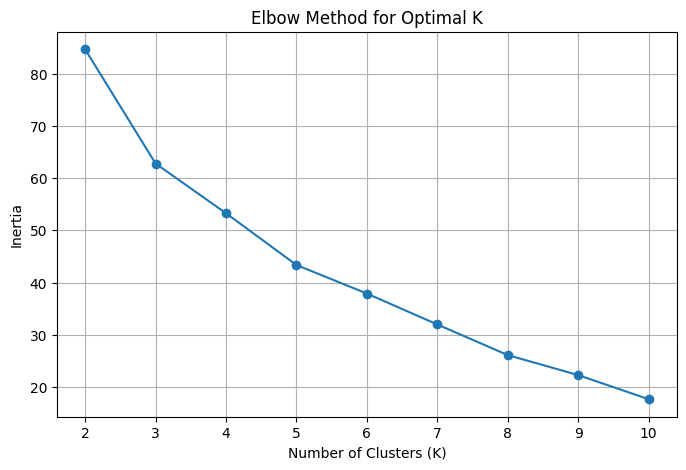

In [225]:
# ============================================
# ELBOW METHOD
# ============================================

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.xticks(range(2, 11))
plt.grid(True)

plt.show()

In [226]:
# ============================================
# STANDARDIZATION
# ============================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Standardization completed!")
print("Scaled data shape:", X_scaled.shape)

Standardization completed!
Scaled data shape: (20, 7)


In [227]:
# ============================================
# CREATE CUSTOMER DATA + FEATURES + X
# ============================================

customer_data = df.groupby("Customer_Name").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum"),
    Total_Quantity=("Quantity", "sum"),
    Average_Discount=("Discount", "mean"),
    Average_Profit_Margin=("Profit_Margin", "mean"),
    Number_of_Orders=("Order_ID", "nunique")
).reset_index()

# Average Order Value
customer_data["Average_Order_Value"] = (
    customer_data["Total_Sales"] /
    customer_data["Number_of_Orders"]
)

# Features used for K-Means
features = [
    "Total_Sales",
    "Total_Profit",
    "Total_Quantity",
    "Average_Discount",
    "Average_Profit_Margin",
    "Number_of_Orders",
    "Average_Order_Value"
]

# Feature matrix
X = customer_data[features]

print("Customer data:", customer_data.shape)
print("Feature matrix:", X.shape)
print("\nFeatures:")
print(features)

Customer data: (20, 8)
Feature matrix: (20, 7)

Features:
['Total_Sales', 'Total_Profit', 'Total_Quantity', 'Average_Discount', 'Average_Profit_Margin', 'Number_of_Orders', 'Average_Order_Value']


In [228]:
features = [
    "Total_Sales",
    "Total_Profit",
    "Total_Quantity",
    "Average_Discount",
    "Average_Profit_Margin",
    "Number_of_Orders",
    "Average_Order_Value"
]

X = customer_data[features]

print("Features selected:")
print(features)

print("\nShape:", X.shape)

Features selected:
['Total_Sales', 'Total_Profit', 'Total_Quantity', 'Average_Discount', 'Average_Profit_Margin', 'Number_of_Orders', 'Average_Order_Value']

Shape: (20, 7)


In [229]:
customer_data = df.groupby("Customer_Name").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum"),
    Total_Quantity=("Quantity", "sum"),
    Average_Discount=("Discount", "mean"),
    Average_Profit_Margin=("Profit_Margin", "mean"),
    Number_of_Orders=("Order_ID", "nunique")
).reset_index()

customer_data["Average_Order_Value"] = (
    customer_data["Total_Sales"] /
    customer_data["Number_of_Orders"]
)

print("Customer-level dataset created!")
print("Number of customers:", len(customer_data))

customer_data.head()

Customer-level dataset created!
Number of customers: 20


,Customer_Name,Total_Sales,Total_Profit,Total_Quantity,Average_Discount,Average_Profit_Margin,Number_of_Orders,Average_Order_Value
0,Aarav Mehta,104215.45,5775.92,663,0.113377,11.266711,228,457.085307
1,Aditya Rao,114766.72,5999.71,678,0.124797,9.930854,246,466.531382
2,Aisha Khan,110822.18,5409.29,705,0.120524,9.478035,229,483.939651
3,Ananya Iyer,141025.62,6825.17,775,0.125316,9.426203,237,595.044810
4,Arjun Nair,120060.81,6571.78,773,0.131800,9.963320,250,480.243240


In [230]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

file_name = list(uploaded.keys())[0]

df = pd.read_excel(
    file_name,
    sheet_name="Sales_Data"
)

print("Sales_Data loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Sales_Data loaded successfully!
Rows: 5000
Columns: 22


,Order_ID,Order_Date,Customer_Name,Customer_Segment,Product_Name,Category,Sub_Category,Region,City,Quantity,...,Sales,Profit,Payment_Method,Year,Month,Month_Number,Quarter,Profit_Margin,Unnamed: 20,Unnamed: 21
0,ORD01158,2023-01-01,Kiara Desai,Corporate,Study Desk,Furniture,Tables,South,Kochi,8,...,1091.56,-44.55,Net Banking,2023,Jan,1,Q1,-4.08,NaN,2.475491e+06
1,ORD01837,2023-01-01,Neel Malhotra,Consumer,Samsung Galaxy A54,Technology,Phones,North,Jaipur,6,...,1641.60,17.95,Debit Card,2023,Jan,1,Q1,1.09,NaN,1.267235e+05
2,ORD03503,2023-01-01,Kabir Shah,Consumer,Ergonomic Office Chair,Furniture,Chairs,North,Amritsar,1,...,121.74,6.76,UPI,2023,Jan,1,Q1,5.55,NaN,1.537600e+04
3,ORD00744,2023-01-02,Rahul Verma,Consumer,Ball Pen Set,Office Supplies,Stationery,East,Guwahati,8,...,56.91,15.00,UPI,2023,Jan,1,Q1,26.36,NaN,5.000000e+03
4,ORD01221,2023-01-02,Diya Sharma,Corporate,Bookshelf,Furniture,Storage,North,Chandigarh,2,...,233.74,28.13,UPI,2023,Jan,1,Q1,12.03,NaN,4.950981e+02
